In [14]:
import brisket
import matplotlib.pyplot as plt
import numpy as np

In [2]:

mc = {'redshift':3, 
      'galaxy':{
        'model':'BC03',
        'logMstar':10,
        'metallicity':0.5,
        'sfh':'constant',
        'age_min':0,
        'age_max':0.5,
        'dust_atten':{
            'type':'Calzetti',
            'Av':3,
        },
        }
    }

gal1 = brisket.model_galaxy(mc, logger=brisket.utils.basicLogger)
from copy import copy
mc['galaxy']['dust_emission'] = {'qpah':4.5, 'umin':20, 'gamma':0.5}
gal2 = brisket.model_galaxy(mc, logger=brisket.utils.basicLogger)



16:13:47 :: brisket :: INFO     :: Loading parameter dictionary
16:13:47 :: brisket :: INFO     :: Calculating optimal wavelength sampling for the model...
16:13:47 :: brisket :: INFO     :: Resampling the filter curves onto model wavelength grid...
16:13:47 :: brisket :: INFO     :: Initializing star-formation history module             (sfh: constant)
16:13:47 :: brisket :: INFO     :: Initializing stellar module                              (model: BC03)
16:13:47 :: brisket :: DEBUG    :: Resampling stellar models to model wavelength grid
16:13:47 :: brisket :: DEBUG    :: Resampling the stellar grids to the configured age sampling
16:13:47 :: brisket :: INFO     :: Skipping nebular emission module
16:13:47 :: brisket :: INFO     :: Initializing dust attenuation module                  (type: Calzetti)
16:13:47 :: brisket :: INFO     :: Skipping dust emission module
16:13:47 :: brisket :: DEBUG    :: Computing stellar spectrum
16:13:47 :: brisket :: DEBUG    :: Converting flux units

16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:15 :: brisket :: DEBUG    :: Converting flux units to f_nu (uJy)
16:30:15 :: brisket :: DEBUG    :: Computing stellar spectrum
16:30:1

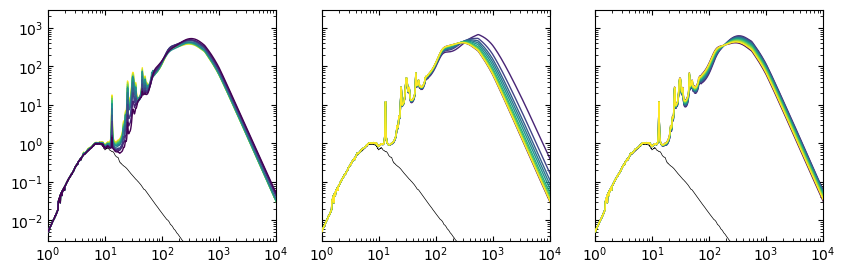

In [47]:
plt.style.use('hba_sans')
fig, axes = plt.subplots(1,3,figsize=(10,3),sharex=True,sharey=True)

for ax in axes: 
    ax.loglog(gal1.wav_obs, gal1.spectrum_full, color='k', linewidth=0.5, zorder=-1000)
    ax.set_xlim(1, 1e4)
    ax.set_ylim(3e-3, 3e3)

cmap = plt.colormaps['viridis']
qpahs = np.linspace(0.15, 4.5, 11)
for i,qpah in enumerate(qpahs):
    mc['galaxy']['dust_emission']['qpah'] = qpah
    gal2.update(mc)
    axes[0].loglog(gal2.wav_obs, gal2.spectrum_full, c=cmap((qpah-qpahs.min())/(qpahs.max()-qpahs.min())), zorder=100-i)

mc['galaxy']['dust_emission']['qpah'] = 3
umins = np.linspace(1, 21, 11)
for i,umin in enumerate(umins):
    gal2.update(mc)
    mc['galaxy']['dust_emission']['umin'] = umin
    axes[1].loglog(gal2.wav_obs, gal2.spectrum_full, c=cmap((umin-umins.min())/(umins.max()-umins.min())), zorder=i)

mc['galaxy']['dust_emission']['umin'] = 20
gammas = np.linspace(0.3,0.7,11)
for i,gamma in enumerate(gammas):
    gal2.update(mc)
    mc['galaxy']['dust_emission']['gamma'] = gamma
    axes[2].loglog(gal2.wav_obs, gal2.spectrum_full, c=cmap((gamma-gammas.min())/(gammas.max()-gammas.min())), zorder=i)


plt.show()